<a href="https://colab.research.google.com/github/oluchiokoro-debug/colab-git-assignment2-OO/blob/main/Unsupervised_Learning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns

# Load dataset
df = sns.load_dataset("penguins")  # alternative clustering dataset
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:
# Check missing values
df.isnull().sum()

# Drop missing values (simple approach)
df = df.dropna()

# Convert categorical variables using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

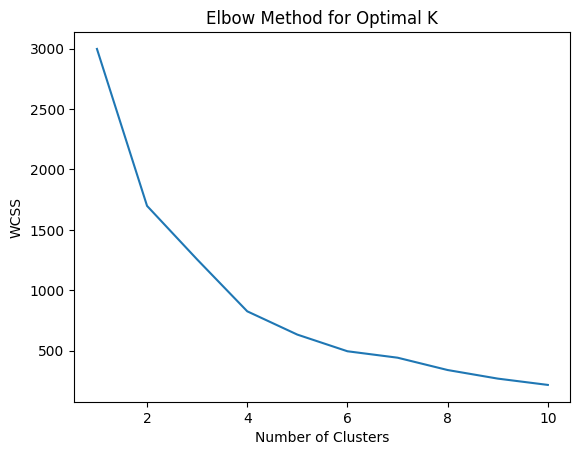

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_kmeans = kmeans.fit_predict(scaled_data)

df['KMeans_Cluster'] = clusters_kmeans

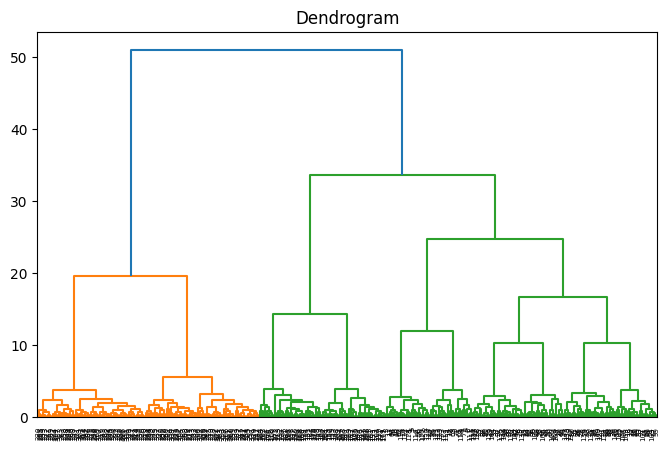

In [5]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(8,5))
dendrogram = sch.dendrogram(sch.linkage(scaled_data, method='ward'))
plt.title("Dendrogram")
plt.show()

# Fit model
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters_hc = hc.fit_predict(scaled_data)

df['HC_Cluster'] = clusters_hc

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

df['PC1'] = principal_components[:, 0]
df['PC2'] = principal_components[:, 1]

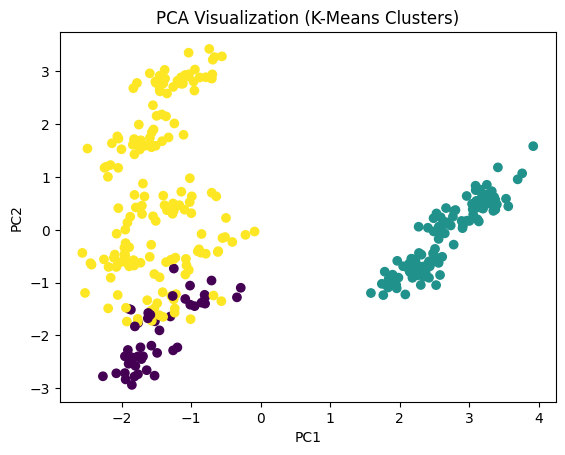

In [7]:
plt.scatter(df['PC1'], df['PC2'], c=df['KMeans_Cluster'], cmap='viridis')
plt.title("PCA Visualization (K-Means Clusters)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [8]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(scaled_data, clusters_kmeans)
hc_score = silhouette_score(scaled_data, clusters_hc)

print("KMeans Silhouette Score:", kmeans_score)
print("Hierarchical Clustering Score:", hc_score)

KMeans Silhouette Score: 0.44103014742395874
Hierarchical Clustering Score: 0.46954259913738616
